# Schematic figures for presentations

Generic, illustrative plots for slides: simple schemes with no ticks, no numbers and no detail, only the idea.
Nothing here uses real data. Every curve is a toy model chosen to *look right*.

Each section writes its figures to `docs/figures/presentation/` (PNG + SVG).
Set `TRANSPARENT = True` to drop the background, so the figure sits on any slide colour.

In [29]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.transforms import Bbox
from scipy.special import ndtr, ndtri

REPO = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "gwuls").is_dir())
OUT = REPO / "docs" / "figures" / "presentation"
OUT.mkdir(parents=True, exist_ok=True)

TRANSPARENT = False
FORMATS = ("png", "svg")

# Same palette as docs/figures/make_setup_model_figures.py
BG, INK, SOFT = "#F7F6F1", "#16213A", "#465267"
BLUE, ORANGE, AQUA, GRAY = "#2A78D6", "#E0662F", "#1BAF7A", "#9AA3AF"

plt.rcParams.update({
    "figure.facecolor": BG, "axes.facecolor": BG, "savefig.facecolor": BG,
    "font.size": 19, "axes.labelsize": 22, "axes.titlesize": 21, "legend.fontsize": 17,
    "text.color": INK, "axes.labelcolor": INK, "axes.edgecolor": INK,
    "savefig.dpi": 200,
})

Z95 = 1.6448536269514722  # one-sided 95% quantile of a unit Gaussian


def gauss(x, mu=0.0, sigma=1.0):
    return np.exp(-0.5 * ((x - mu) / sigma) ** 2) / (sigma * np.sqrt(2 * np.pi))


def schematic_axes(ax, xlabel=None, ylabel=None, yaxis=True):
    """Bare axes: no ticks, no grid, only left/bottom spines ending in arrowheads."""
    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(False)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    for s in ("left", "bottom"):
        ax.spines[s].set_linewidth(1.8)
    ax.plot(1, 0, ">", color=INK, ms=9, transform=ax.transAxes, clip_on=False)
    if yaxis:
        ax.plot(0, 1, "^", color=INK, ms=9, transform=ax.transAxes, clip_on=False)
    else:
        ax.spines["left"].set_visible(False)
    if xlabel:
        ax.set_xlabel(xlabel, loc="right")
    if ylabel:
        ax.set_ylabel(ylabel, loc="top")


def save(fig, name, bbox_inches="tight"):
    for ext in FORMATS:
        fig.savefig(OUT / f"{name}.{ext}", bbox_inches=bbox_inches, transparent=TRANSPARENT)
    print("saved", OUT / name, FORMATS)

## 1. $\Lambda$ distributions: background vs injected signal

Three injected fluxes, from low to high. The grey curve is the background-only $\Lambda$ distribution, the blue one
is $\Lambda$ with a signal injected. The shaded blue area is the fraction of injected realisations that fall
below $\Lambda_\mathrm{target}$.

* **left:** low flux, the injected distribution barely moves away from the background.
* **centre:** the flux at the UL, only 5% of the injected distribution is left of $\Lambda_\mathrm{target}$.
* **right:** too high a flux, the injected distribution sits entirely to the right.

saved /home/jjimenezq/projects/gw-gamma-global-uls/docs/figures/presentation/lambda_distributions_ul ('png', 'svg')


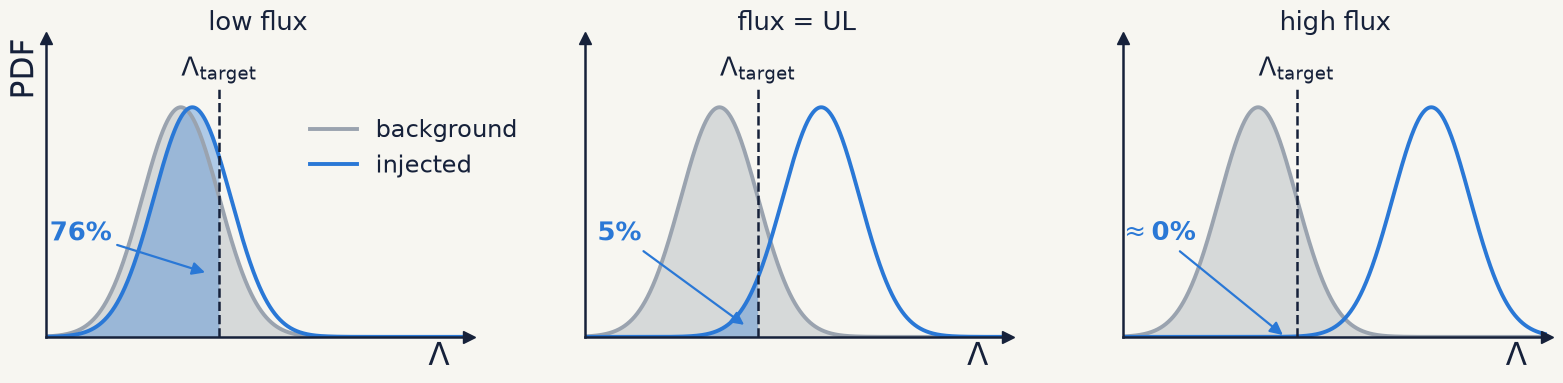

In [30]:
SIGMA = 1.0
LAM_T = 1.0                      # target Lambda (vertical dashed line)
PANELS = {                       # title -> mean of the injected Gaussian
    "low flux": 0.3,
    "flux = UL": LAM_T + Z95 * SIGMA,   # exactly 5% left of LAM_T
    "high flux": LAM_T + 3.5 * SIGMA,
}
X_LAM = np.linspace(-3.5, 7.5, 1000)
PEAK = gauss(0.0, sigma=SIGMA)


def draw_lambda_panel(ax, mu, title=None, annotate=True, small=False):
    """Background and injected Lambda distributions, the target line and the shaded tail below it."""
    x, lw, fs = X_LAM, (2.0 if small else 2.8), (15 if small else None)
    left = x <= LAM_T
    bkg, inj = gauss(x, sigma=SIGMA), gauss(x, mu, SIGMA)
    ax.fill_between(x, bkg, color=GRAY, alpha=0.35, lw=0)
    ax.plot(x, bkg, color=GRAY, lw=lw, label="background")
    ax.fill_between(x[left], inj[left], color=BLUE, alpha=0.35, lw=0)
    ax.plot(x, inj, color=BLUE, lw=lw, label="injected")

    ax.vlines(LAM_T, 0, 1.08 * PEAK, color=INK, ls="--", lw=1.8)
    ax.text(LAM_T, 1.1 * PEAK, r"$\Lambda_\mathrm{target}$", ha="center", va="bottom", fontsize=fs)

    if annotate:
        frac = ndtr((LAM_T - mu) / SIGMA)
        label = f"{100 * frac:.0f}%" if frac >= 0.005 else r"$\approx$0%"
        x_arrow = LAM_T - 0.3
        ax.annotate(label, xy=(x_arrow, 0.3 * gauss(x_arrow, mu, SIGMA)), xytext=(-2.6, 0.45 * PEAK),
                    ha="center", va="center", color=BLUE, fontweight="bold",
                    arrowprops=dict(arrowstyle="-|>", color=BLUE, lw=1.6))

    ax.set_xlim(x[0], x[-1])
    ax.set_ylim(0, 1.3 * PEAK)
    if title:
        ax.set_title(title, fontsize=fs)


fig, axes = plt.subplots(1, 3, figsize=(16, 4.2), sharey=True)
for i, (ax, (title, mu)) in enumerate(zip(axes, PANELS.items())):
    draw_lambda_panel(ax, mu, title)
    schematic_axes(ax, xlabel=r"$\Lambda$  ", ylabel="PDF" if i == 0 else None)

axes[0].legend(frameon=False, loc=(0.6, 0.5))
fig.tight_layout()
save(fig, "lambda_distributions_ul")
plt.show()

## 2. Finding the UL flux: the probit fit

How `simulate._fit_ul` finds the flux of section 1's centre panel without scanning fluxes one by one
(details in `docs/physics_and_methods.md`, §7.3). Meant to be shown in order:

* **2a** — from $\Lambda$ distributions to one curve: the detection probability $f(x) = P(\Lambda_x > \Lambda_\mathrm{target})$
  against the injected flux. It starts at $f_0$ (background only), rises, and the UL is where it crosses CL = 95%.
* **2b** — what is actually simulated: each realisation gets its **own** flux $x_i$ and gives a yes/no outcome
  $y_i = \mathbf 1[\Lambda_i > \Lambda_\mathrm{target}]$. A probit is fitted to all the 0s and 1s at once.
* **2c** — the rounds: a scout over the whole bracket, then batches placed in the window where the curve
  carries the information about $x_\mathrm{UL}$. The band shrinks every round.
* **2d** — the stopping rule: the profile likelihood of $\log x_\mathrm{UL}$ narrows until its $1\sigma$ half-width
  is below the requested precision.
* **2e** — adding a variable (the viewing angle $\theta$): the same realisations spread over a plane instead of a
  line, so more are needed for the same precision, and the limit itself moves.

The curve is a probit in $\log x$ centred on the plot, with the background level $f_0$ of section 1, and the
three dots of 2a sit at the detection probabilities of section 1's panels.

In [31]:
CL = 0.95
F0 = ndtr(-LAM_T / SIGMA)            # detection probability with no signal, as in section 1
S = 0.8                              # width of the transition, in log-flux units
T = np.linspace(-3.2, 3.2, 600)      # log injected flux; the S is centred at 0
T_UL = S * ndtri((CL - F0) / (1 - F0))


def detection_prob(t, t_mid=0.0):
    """Toy detection probability P(Lambda > target) at log flux t."""
    return F0 + (1 - F0) * ndtr((t - t_mid) / S)


def t_of_prob(p):
    """Inverse of detection_prob, clipped so that p ~ 1 stays on the plot."""
    return S * ndtri(np.clip((p - F0) / (1 - F0), 1e-3, 1 - 1e-3))


def cl_line(ax, t_ul=T_UL, label=True):
    ax.hlines(CL, T[0], T[-1], color=INK, ls="--", lw=1.6)
    ax.vlines(t_ul, 0, CL, color=INK, ls=":", lw=1.8)
    if label:
        ax.text(T[0] + 0.1, CL + 0.02, "CL = 95%", va="bottom")
        ax.text(t_ul + 0.08, 0.03, "UL", va="bottom", fontweight="bold")


rng = np.random.default_rng(3)


def realisations(n, lo, hi):
    """n realisations with log flux uniform in [lo, hi] and their Bernoulli outcomes."""
    t = rng.uniform(lo, hi, n)
    return t, rng.random(n) < detection_prob(t)


def draw_outcomes(ax, t, y, alpha=1.0, ms=6, labels=False):
    jitter = rng.uniform(-0.025, 0.025, t.size)
    ax.plot(t[y], 1 + jitter[y], "o", color=BLUE, ms=ms, alpha=alpha, mew=0,
            label=r"$\Lambda_i > \Lambda_\mathrm{target}$  ($y_i = 1$)" if labels else None)
    ax.plot(t[~y], jitter[~y], "o", color=GRAY, ms=ms, alpha=alpha, mew=0,
            label=r"$\Lambda_i < \Lambda_\mathrm{target}$  ($y_i = 0$)" if labels else None)

### 2a. From $\Lambda$ distributions to the detection probability

saved /home/jjimenezq/projects/gw-gamma-global-uls/docs/figures/presentation/probit_from_lambda ('png', 'svg')


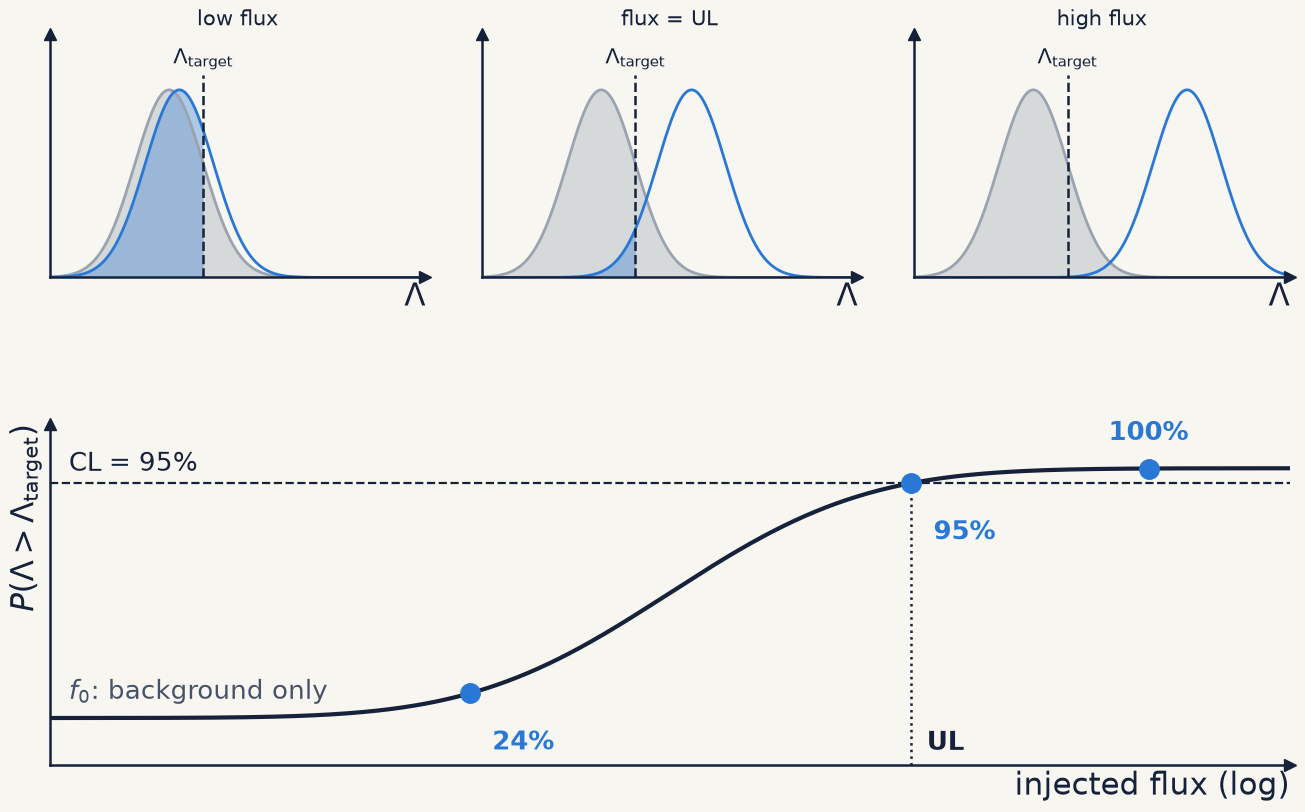

In [32]:
fig = plt.figure(figsize=(16, 9.5))
gs = fig.add_gridspec(2, 3, height_ratios=[1, 1.4], hspace=0.5, wspace=0.15)
for j, (title, mu) in enumerate(PANELS.items()):
    ax = fig.add_subplot(gs[0, j])
    draw_lambda_panel(ax, mu, title, annotate=False, small=True)
    schematic_axes(ax, xlabel=r"$\Lambda$")

ax = fig.add_subplot(gs[1, :])
ax.plot(T, detection_prob(T), color=INK, lw=3)
cl_line(ax)
ax.text(T[0] + 0.1, F0 + 0.04, r"$f_0$: background only", va="bottom", color=SOFT)
# (offset, ha, va) of each percentage label: below-right of the dot, above it for the last one
LABELS = (((16, -26), "left", "top"), ((16, -26), "left", "top"), ((0, 16), "center", "bottom"))
for mu, (offset, ha, va) in zip(PANELS.values(), LABELS):
    p = ndtr((mu - LAM_T) / SIGMA)              # fraction above the target in section 1
    t = t_of_prob(p)
    ax.plot(t, detection_prob(t), "o", color=BLUE, ms=14, zorder=3)
    ax.annotate(f"{100 * p:.0f}%", (t, detection_prob(t)), xytext=offset, textcoords="offset points",
                ha=ha, va=va, color=BLUE, fontweight="bold")
ax.set_xlim(T[0], T[-1])
ax.set_ylim(0, 1.15)
schematic_axes(ax, xlabel="injected flux (log)", ylabel=r"$P(\Lambda > \Lambda_\mathrm{target})$")

save(fig, "probit_from_lambda")
plt.show()

### 2b. One flux per realisation, one fit to all the outcomes

saved /home/jjimenezq/projects/gw-gamma-global-uls/docs/figures/presentation/probit_realisations ('png', 'svg')


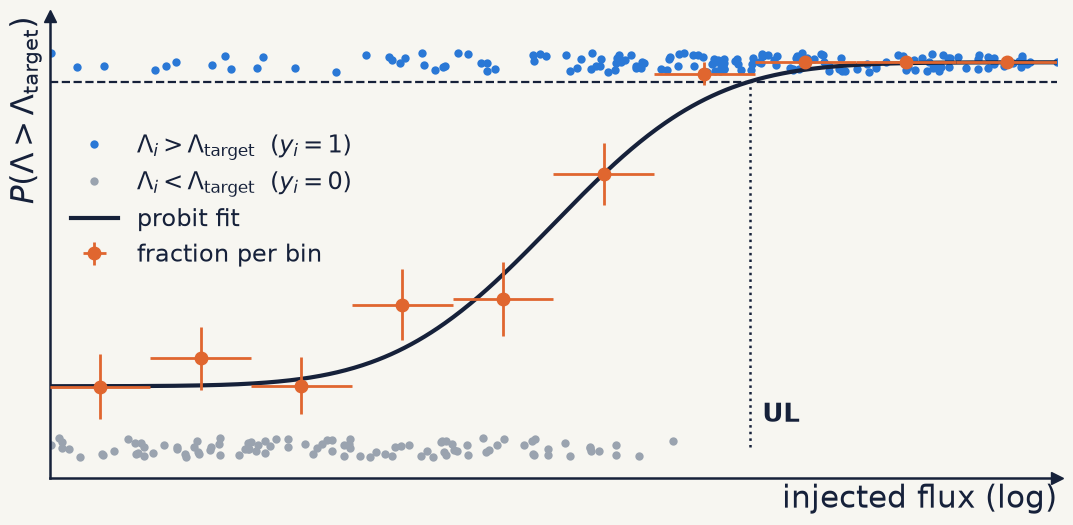

In [33]:
t, y = realisations(260, T[0], T[-1])
edges = np.linspace(T[0], T[-1], 11)
n, _ = np.histogram(t, edges)
k, _ = np.histogram(t[y], edges)
frac = k / n

fig, ax = plt.subplots(figsize=(13, 6))
draw_outcomes(ax, t, y, labels=True)
ax.errorbar(0.5 * (edges[1:] + edges[:-1]), frac, xerr=0.5 * np.diff(edges),
            yerr=np.sqrt(frac * (1 - frac) / n), fmt="o", color=ORANGE, ms=9, lw=2, capsize=0,
            zorder=4, label="fraction per bin")
ax.plot(T, detection_prob(T), color=INK, lw=3, label="probit fit")
cl_line(ax, label=False)
ax.text(T_UL + 0.08, 0.05, "UL", va="bottom", fontweight="bold")
ax.set_xlim(T[0], T[-1])
ax.set_ylim(-0.08, 1.12)
ax.legend(frameon=False, loc="center left", bbox_to_anchor=(0.0, 0.6))
schematic_axes(ax, xlabel="injected flux (log)", ylabel=r"$P(\Lambda > \Lambda_\mathrm{target})$")

save(fig, "probit_realisations")
plt.show()

### 2c. Rounds: scout, then refine where the curve matters

The fit estimate (orange, $\pm 1\sigma$) and its band are drawn by hand: offsets and widths that shrink each round.

saved /home/jjimenezq/projects/gw-gamma-global-uls/docs/figures/presentation/probit_rounds ('png', 'svg')


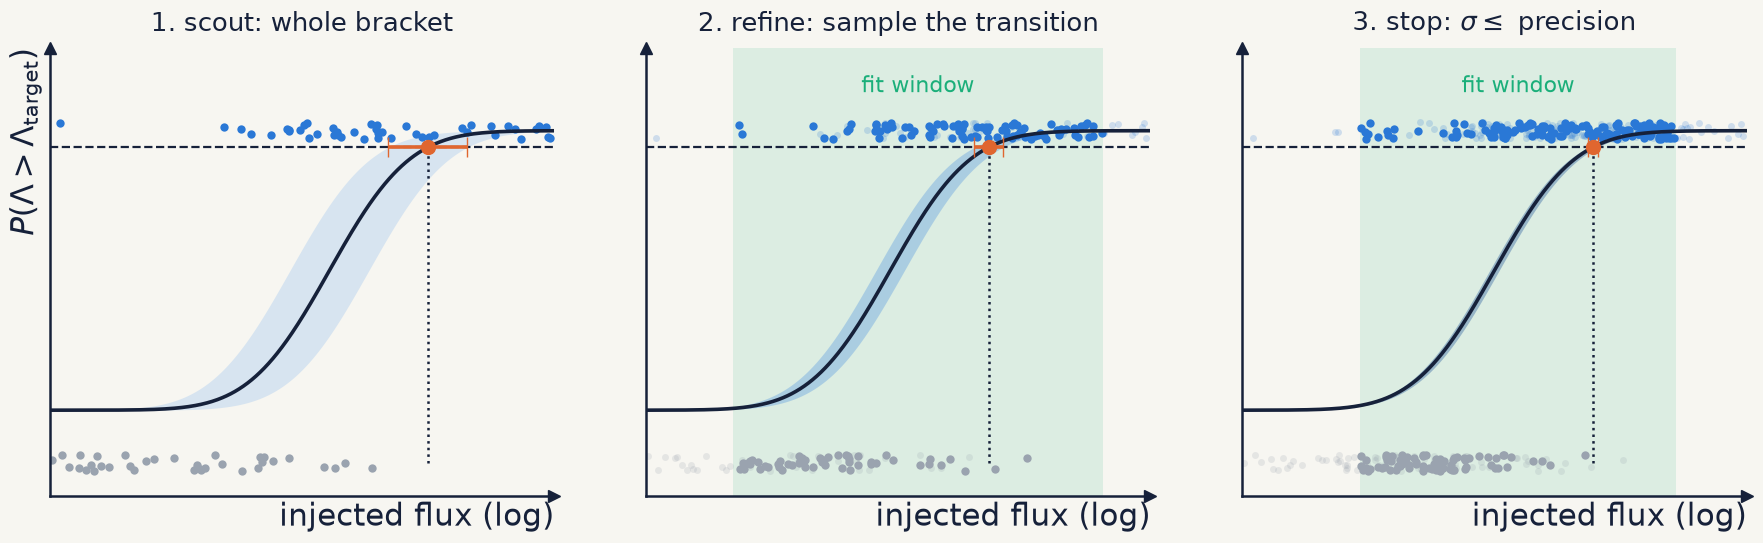

In [34]:
ROUND_NAMES = ("scout", "refine", "converged")
ROUND_COLORS = ("#9cc3f0", "#4f94e0", "#184f95")
SE = (0.5, 0.18, 0.06)            # 1 sigma on log x_UL after each round, illustrative
OFFSETS = (0.35, -0.1, 0.0)       # fitted minus true log x_UL, illustrative
WINDOWS = ((T[0], T[-1]), (-2.1, 2.6), (-1.7, 2.3))   # where each round's realisations go
DESIGN = (80, 140, 220)           # realisations per round

rounds = [realisations(n, *w) for n, w in zip(DESIGN, WINDOWS)]

titles = ("1. scout: whole bracket", "2. refine: sample the transition", r"3. stop: $\sigma \leq$ precision")
fig, axes = plt.subplots(1, 3, figsize=(18, 5.8), sharey=True)
for r, ax in enumerate(axes):
    if r > 0:
        lo, hi = WINDOWS[r]
        ax.axvspan(lo, hi, color=AQUA, alpha=0.12, lw=0)
        ax.text(0.5 * (lo + hi), 1.1, "fit window", ha="center", va="bottom", color=AQUA, fontsize=16)
    for k in range(r):
        draw_outcomes(ax, *rounds[k], alpha=0.2, ms=5)
    draw_outcomes(ax, *rounds[r], ms=6)

    t_hat, se = T_UL + OFFSETS[r], SE[r]
    ax.fill_between(T, detection_prob(T - OFFSETS[r] - se), detection_prob(T - OFFSETS[r] + se),
                    color=ROUND_COLORS[r], alpha=0.35, lw=0)
    ax.plot(T, detection_prob(T - OFFSETS[r]), color=INK, lw=2.6)
    cl_line(ax, t_ul=t_hat, label=False)
    ax.errorbar(t_hat, CL, xerr=se, fmt="o", color=ORANGE, ms=10, capsize=7, lw=2.6, zorder=4)

    ax.set_xlim(T[0], T[-1])
    ax.set_ylim(-0.1, 1.25)
    ax.set_title(titles[r], fontsize=19, pad=12)
    schematic_axes(ax, xlabel="injected flux (log)",
                   ylabel=r"$P(\Lambda > \Lambda_\mathrm{target})$" if r == 0 else None)

fig.tight_layout(w_pad=3)
save(fig, "probit_rounds")
plt.show()

### 2d. Stopping rule: the profile likelihood of the UL

saved /home/jjimenezq/projects/gw-gamma-global-uls/docs/figures/presentation/probit_profile ('png', 'svg')


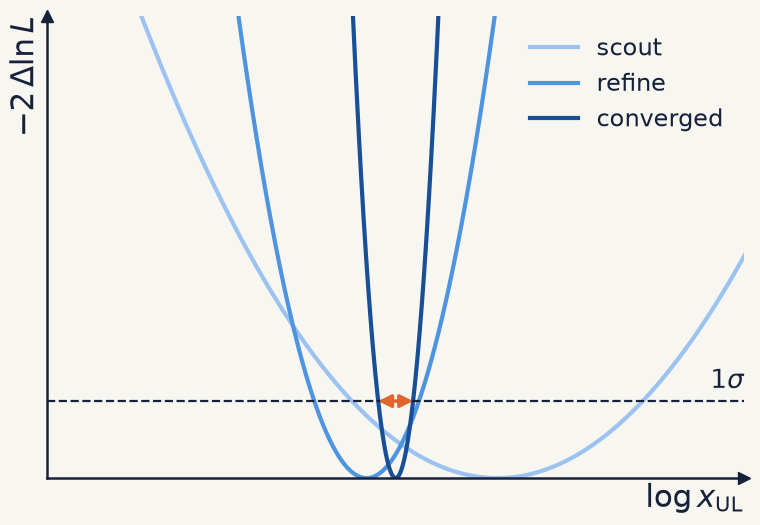

In [35]:
u = np.linspace(T_UL - 1.2, T_UL + 1.2, 600)

fig, ax = plt.subplots(figsize=(9, 6))
for name, color, se, off in zip(ROUND_NAMES, ROUND_COLORS, SE, OFFSETS):
    ax.plot(u, ((u - T_UL - off) / se) ** 2, color=color, lw=3, label=name)
ax.hlines(1, u[0], u[-1], color=INK, ls="--", lw=1.6)
ax.text(u[-1], 1.08, r"$1\sigma$", ha="right", va="bottom")
ax.annotate("", xy=(T_UL - SE[-1], 1), xytext=(T_UL + SE[-1], 1),
            arrowprops=dict(arrowstyle="<|-|>", color=ORANGE, lw=2.4, shrinkA=0, shrinkB=0))
ax.set_xlim(u[0], u[-1])
ax.set_ylim(0, 6)
ax.legend(frameon=False, loc="upper right")
schematic_axes(ax, xlabel=r"$\log x_\mathrm{UL}$", ylabel=r"$-2\,\Delta \ln L$")

save(fig, "probit_profile")
plt.show()

### 2e. Adding a variable: the viewing angle $\theta$

* **left:** flux only. $N$ realisations on a line fill it densely; the background shade is the detection probability.
* **centre:** flux and $\theta$. The same $N$ realisations now spread over a plane. Off-axis sources are dimmer, so
  the 95% contour bends towards higher flux as $\theta$ grows, and much of the plane is barely sampled.
* **right:** the UL over repeated runs (illustrative). With the same $N$ it scatters far more and sits at a higher
  flux, since the limit has to cover the unfavourable angles too; more realisations bring the scatter back down.

saved /home/jjimenezq/projects/gw-gamma-global-uls/docs/figures/presentation/probit_extra_variable ('png', 'svg')


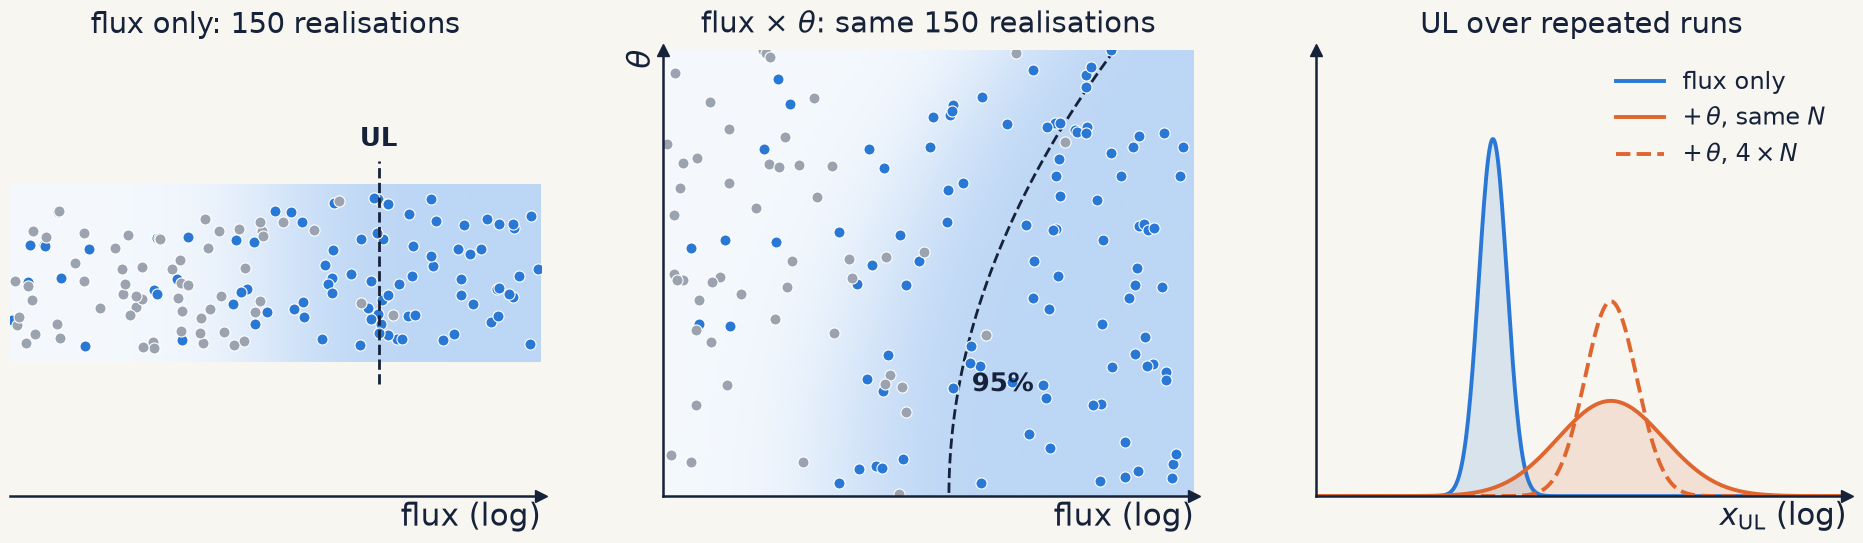

In [36]:
N = 150
TH = np.linspace(0, 1, 300)
DET_CMAP = LinearSegmentedColormap.from_list("det", ["#FFFFFF", "#bcd6f5"])


def t_mid_theta(th):
    """Centre of the S at viewing angle th (0 on-axis, 1 most off-axis): off-axis needs more flux."""
    return -1.0 + 2.0 * th ** 2


def draw_points(ax, t, v, y):
    ax.plot(t[y], v[y], "o", color=BLUE, mec="white", mew=0.8, ms=8)
    ax.plot(t[~y], v[~y], "o", color=GRAY, mec="white", mew=0.8, ms=8)


fig, axes = plt.subplots(1, 3, figsize=(19, 5.8))

ax = axes[0]
ax.imshow(detection_prob(T)[None, :], extent=(T[0], T[-1], 0.3, 0.7), origin="lower", aspect="auto",
          cmap=DET_CMAP, vmin=0, vmax=1)
t1, y1 = realisations(N, T[0], T[-1])
draw_points(ax, t1, rng.uniform(0.33, 0.67, N), y1)
ax.vlines(T_UL, 0.25, 0.75, color=INK, ls="--", lw=2)
ax.text(T_UL, 0.77, "UL", ha="center", va="bottom", fontweight="bold")
ax.set_xlim(T[0], T[-1])
ax.set_ylim(0, 1)
ax.set_title(f"flux only: {N} realisations", pad=12)
schematic_axes(ax, xlabel="flux (log)", yaxis=False)

ax = axes[1]
p2 = detection_prob(T[None, :], t_mid_theta(TH[:, None]))
ax.imshow(p2, extent=(T[0], T[-1], 0, 1), origin="lower", aspect="auto", cmap=DET_CMAP, vmin=0, vmax=1)
ax.contour(T, TH, p2, levels=[CL], colors=INK, linestyles="--", linewidths=2)
t2, th2 = rng.uniform(T[0], T[-1], N), rng.uniform(0, 1, N)
draw_points(ax, t2, th2, rng.random(N) < detection_prob(t2, t_mid_theta(th2)))
ax.text(t_mid_theta(0.25) + T_UL + 0.15, 0.25, "95%", va="center", fontweight="bold")
ax.set_xlim(T[0], T[-1])
ax.set_ylim(0, 1)
ax.set_title(rf"flux $\times$ $\theta$: same {N} realisations", pad=12)
schematic_axes(ax, xlabel="flux (log)", ylabel=r"$\theta$")

ax = axes[2]
v = np.linspace(-1.5, 3.0, 500)
CASES = (   # label, centre, width, colour, line style
    ("flux only", 0.0, 0.12, BLUE, "-"),
    (rf"$+\,\theta$, same $N$", 1.0, 0.45, ORANGE, "-"),
    (rf"$+\,\theta$, $4\times N$", 1.0, 0.22, ORANGE, "--"),
)
for label, c, w, color, ls in CASES:
    pdf = gauss(v, c, w)
    if ls == "-":
        ax.fill_between(v, pdf, color=color, alpha=0.15, lw=0)
    ax.plot(v, pdf, color=color, lw=2.8, ls=ls, label=label)
ax.set_xlim(v[0], v[-1])
ax.set_ylim(0, 1.25 * gauss(0.0, 0.0, 0.12))
ax.legend(frameon=False, loc="upper right")
ax.set_title("UL over repeated runs", pad=12)
schematic_axes(ax, xlabel=r"$x_\mathrm{UL}$ (log)")

fig.tight_layout(w_pad=3)
save(fig, "probit_extra_variable")
plt.show()

## 3. How a simulated source is drawn

Every realisation injects one possible GW counterpart, picked as **one row of the PE posterior**: its sky position
$\Omega$, distance $d$ and viewing angle $\theta_v$ come together (details in `notebooks/illustrate_source_sampling.ipynb`
and `docs/viewing_angle_distribution.md`).

The draws are shown in 3D from Earth: spread over the localisation on the sky and in depth along their lines of
sight, coloured by $\theta_v$. Face-on binaries are louder, so the far draws are mostly face-on: $d$ and
$\theta_v$ are correlated, which is why they are drawn together. Two figures with identical framing, one per slide: `source_cloud` shows the draws alone, `source_selection`
adds one drawn source in orange, with a mock jet tilted by its $\theta_v$ from the line of sight.

saved /home/jjimenezq/projects/gw-gamma-global-uls/docs/figures/presentation/source_cloud ('png', 'svg')


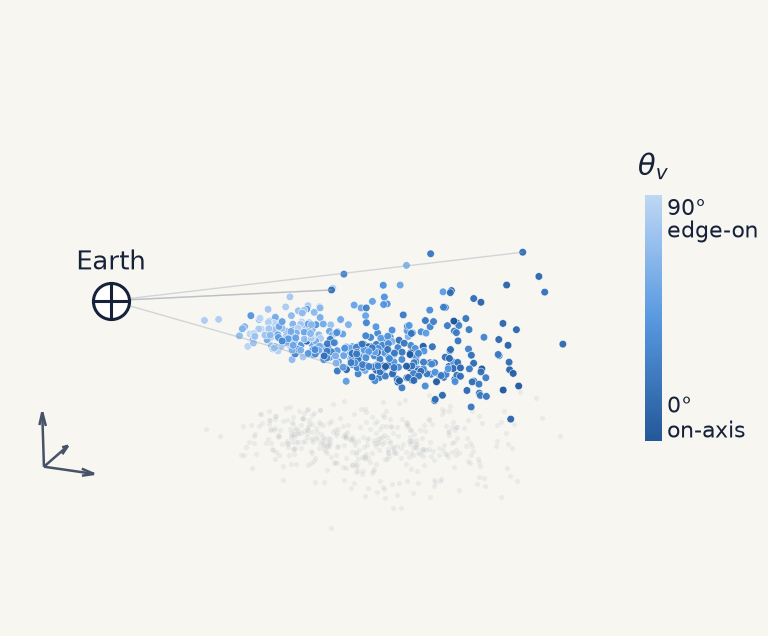

saved /home/jjimenezq/projects/gw-gamma-global-uls/docs/figures/presentation/source_selection ('png', 'svg')


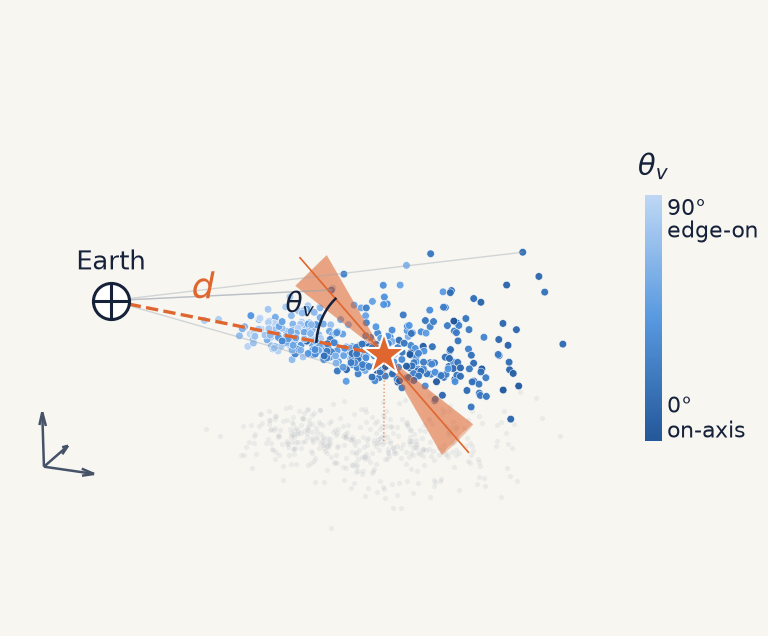

In [37]:
rng3 = np.random.default_rng(7)
N_PE = 1500

# Toy PE posterior: banana in the sky; cos(theta_v) favouring face-on (louder); d larger when face-on.
pe_ra = 2.8 * rng3.normal(size=N_PE)
pe_dec = 0.07 * pe_ra ** 2 - 1.0 + 0.45 * rng3.normal(size=N_PE)
cos_t = rng3.uniform(0, 1, 20 * N_PE)
cos_t = cos_t[rng3.random(cos_t.size) < ((1 + cos_t ** 2) / 2) ** 3][:N_PE]
pe_theta = np.degrees(np.arccos(cos_t))
pe_d = (1 + cos_t ** 2) / 2 * np.exp(0.15 * rng3.normal(size=N_PE))
I_STAR = int(np.argmin(np.abs(pe_theta - 40) + 5 * np.abs(pe_ra / 2.8)))   # the highlighted draw

THETA_CMAP = LinearSegmentedColormap.from_list("theta", ["#184f95", "#4f94e0", "#bcd6f5"])

k = 0.07                                           # sky offset -> transverse position
x, y, z = pe_d, pe_d * k * pe_ra, pe_d * k * pe_dec
show = slice(0, 400)
Z_FLOOR = -0.3                                     # plane the shadows fall on

# the same scene twice: the cloud alone, then with one drawn source picked out in orange
for selected in (False, True):
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(projection="3d", computed_zorder=False)
    ax.set_axis_off()

    # shadows on the floor, for depth
    ax.scatter(x[show], y[show], np.full(x[show].shape, Z_FLOOR), s=14, color=GRAY, alpha=0.13, lw=0,
               depthshade=False)

    # lines of sight to the edges of the localisation
    shown = np.arange(N_PE)[show]
    for j in shown[np.concatenate([np.argsort(pe_ra[show])[[0, -1]], np.argsort(pe_dec[show])[[0, -1]]])]:
        ax.plot([0, x[j]], [0, y[j]], [0, z[j]], color=GRAY, lw=1, alpha=0.4)
    sc = ax.scatter(x[show], y[show], z[show], c=pe_theta[show], cmap=THETA_CMAP, vmin=0, vmax=90,
                    s=30, alpha=0.95, edgecolors="white", linewidths=0.4, depthshade=False)
    # the drawn source, only in the second figure
    if selected:
        ax.plot([0, x[I_STAR]], [0, y[I_STAR]], [0, z[I_STAR]], color=ORANGE, ls="--", lw=2.4)
        # mock jet on the drawn source: a double cone tilted by theta_v from the line of sight back to Earth
        src = np.array([x[I_STAR], y[I_STAR], z[I_STAR]])
        los = -src / np.linalg.norm(src)                   # source -> Earth
        u = np.array([0, 0, 1.0]) - los[2] * los           # tilt "upwards", perpendicular to the line of sight
        u /= np.linalg.norm(u)
        th = np.radians(pe_theta[I_STAR])
        jet_ax = np.cos(th) * los + np.sin(th) * u
        v = np.cross(jet_ax, u)
        v /= np.linalg.norm(v)
        w = np.cross(jet_ax, v)
        L_JET, OPEN = 0.3, np.radians(11)
        s_, phi = np.meshgrid(np.linspace(0, L_JET, 2), np.linspace(0, 2 * np.pi, 40))
        for sign in (1, -1):
            r = s_ * np.tan(OPEN)
            cone = [src[i] + sign * s_ * jet_ax[i] + r * (np.cos(phi) * v[i] + np.sin(phi) * w[i]) for i in range(3)]
            ax.plot_surface(*cone, color=ORANGE, alpha=0.35, lw=0, shade=False)
            ax.plot(*np.array([src, src + sign * 1.15 * L_JET * jet_ax]).T, color=ORANGE, lw=1.2)
        arc = np.linspace(0, th, 30)
        arc = src + 0.2 * (np.cos(arc)[:, None] * los + np.sin(arc)[:, None] * u)
        ax.plot(*arc.T, color=INK, lw=1.8)
        mid = src + 0.27 * (np.cos(th / 2) * los + np.sin(th / 2) * u)
        ax.text(*mid, r"$\theta_v$", color=INK, fontsize=20, ha="center", va="center")
        ax.plot([x[I_STAR]], [y[I_STAR]], [z[I_STAR]], marker="*", ms=32, color=ORANGE, mec="white", mew=1.5)
        ax.plot([x[I_STAR]] * 2, [y[I_STAR]] * 2, [Z_FLOOR, z[I_STAR]], color=ORANGE, lw=1, ls=":", alpha=0.7)
        ax.text(0.3 * x[I_STAR], 0.3 * y[I_STAR], 0.3 * z[I_STAR] + 0.05, "$d$", color=ORANGE, fontsize=26)

    # Earth: the astronomical symbol, a circle with a cross
    ax.plot([0], [0], [0], marker="o", ms=26, mfc="white", mec=INK, mew=2.2)
    ax.plot([0], [0], [0], marker="+", ms=26, mec=INK, mew=2.2)
    ax.text(0, 0, 0.07, "Earth", ha="center", va="bottom", color=INK)

    # small unlabeled axis triad on the floor, in the front corner
    o, L = np.array([0.0, -0.45, Z_FLOOR]), 0.15
    for d in np.eye(3):
        ax.quiver(*o, *(L * d), color=SOFT, lw=1.8, arrow_length_ratio=0.25)

    ax.set_xlim(-0.1, 1.4)
    ax.set_ylim(-0.7, 0.7)
    ax.set_zlim(-0.35, 0.45)
    ax.set_box_aspect((1.4, 1.4, 0.8), zoom=1.3)
    ax.view_init(elev=20, azim=-70)

    cb = fig.colorbar(sc, ax=ax, shrink=0.4, aspect=14, pad=0.02)
    cb.set_ticks([0, 90])
    cb.set_ticklabels(["0°\non-axis", "90°\nedge-on"], color=INK, linespacing=1.1)
    cb.ax.tick_params(length=0, labelsize=16)
    lo_lab, hi_lab = cb.ax.get_yticklabels()             # align them with the ends of the bar
    lo_lab.set_va("bottom")
    hi_lab.set_va("top")
    cb.ax.set_title(r"$\theta_v$", color=INK, pad=14)
    cb.outline.set_visible(False)

    # a 3D axes always reserves a square-ish box: crop the empty margins above and below it.
    # The fixed box (not "tight") also keeps both figures framed identically.
    save(fig, "source_selection" if selected else "source_cloud", bbox_inches=Bbox([[2.6, 1.45], [11.3, 6.2]]))
    plt.show()